In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import tensorflow as tf

In [2]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(224,224),
    batch_size=32
)

Found 294 files belonging to 2 classes.
Using 236 files for training.
Found 294 files belonging to 2 classes.
Using 58 files for validation.
Found 97 files belonging to 2 classes.


In [3]:
class_names = train_dataset.class_names

print(class_names)

['apples', 'tomatoes']


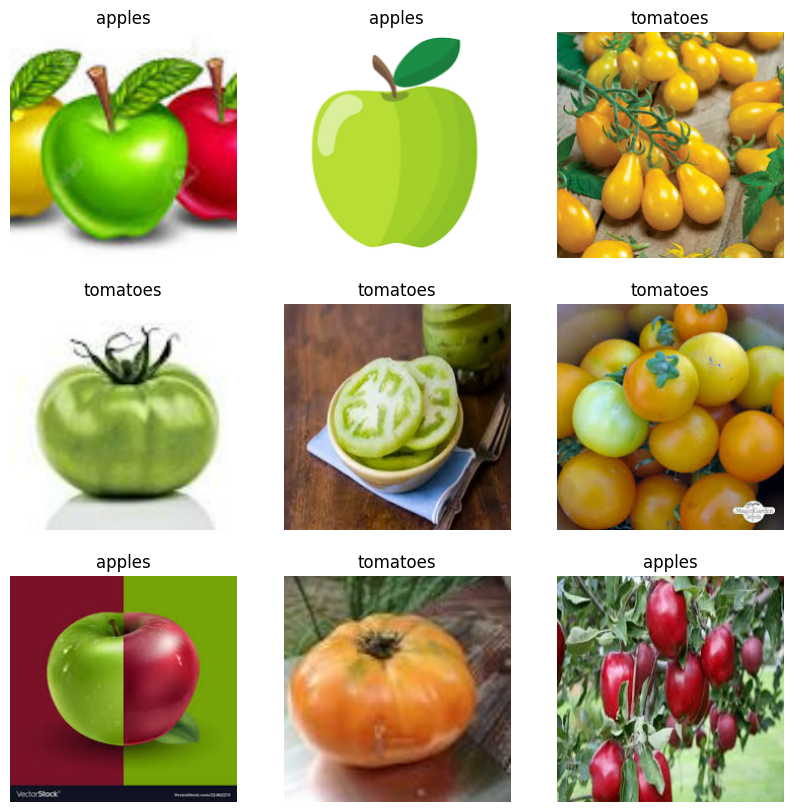

In [12]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode='horizontal', seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [14]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer= tf.keras.optimizers.Adam(),
              metrics=['accuracy'])


model.fit(train_dataset, validation_data=valid_dataset, epochs=5)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 504ms/step - accuracy: 0.5381 - loss: 6.0759 - val_accuracy: 0.6724 - val_loss: 0.7739
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.6314 - loss: 0.6758 - val_accuracy: 0.6207 - val_loss: 0.6497
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 461ms/step - accuracy: 0.6822 - loss: 0.5997 - val_accuracy: 0.7069 - val_loss: 0.5940
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 586ms/step - accuracy: 0.6949 - loss: 0.5825 - val_accuracy: 0.7241 - val_loss: 0.5455
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.7966 - loss: 0.5006 - val_accuracy: 0.6552 - val_loss: 0.6593


In [16]:
model2 =None

In [17]:
tf.random.set_seed(42)

model2 = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding="same",kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding="same",kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])


model2.fit(train_dataset, validation_data=valid_dataset, epochs=20)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 460ms/step - accuracy: 0.5551 - loss: 246.6229 - val_accuracy: 0.3793 - val_loss: 0.7505
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.6017 - loss: 0.6937 - val_accuracy: 0.6034 - val_loss: 1.0039
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 555ms/step - accuracy: 0.5975 - loss: 0.7196 - val_accuracy: 0.7241 - val_loss: 0.6682
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 562ms/step - accuracy: 0.6271 - loss: 0.6737 - val_accuracy: 0.6379 - val_loss: 0.7245
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 539ms/step - accuracy: 0.6864 - loss: 0.6511 - val_accuracy: 0.6379 - val_loss: 0.6693
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 544ms/step - accuracy: 0.6271 - loss: 0.6624 - val_accuracy: 0.7069 - val_loss: 0.6566
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.6610 - loss: 0.6218 - val_accuracy: 0.6897 - val_loss: 0.6851
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step - accuracy: 0.6525 - loss: 0.6108 - val_accuracy: 0.7241 - val_los

Lets find best learning rate:

In [18]:
tf.random.set_seed(42)


model3 = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding="same",kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding="same",kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))


find_lr_history = model3.fit(train_dataset, validation_data=valid_dataset, epochs=40,
           callbacks=[lr_scheduler])

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 478ms/step - accuracy: 0.5593 - loss: 33.5579 - val_accuracy: 0.6034 - val_loss: 8.7902 - learning_rate: 0.0010
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.5551 - loss: 7.5617 - val_accuracy: 0.6724 - val_loss: 1.0832 - learning_rate: 0.0011
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 462ms/step - accuracy: 0.6398 - loss: 1.3441 - val_accuracy: 0.7414 - val_loss: 0.7318 - learning_rate: 0.0013
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 441ms/step - accuracy: 0.7203 - loss: 0.7101 - val_accuracy: 0.5862 - val_loss: 0.6564 - learning_rate: 0.0014
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 438ms/step - accuracy: 0.7415 - loss: 0.5502 - val_accuracy: 0.6207 - val_loss: 0.6645 - learning_rate: 0.0016
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 433ms/step - accuracy: 0.7966 - loss: 0.4732 - val_accuracy: 0.7069 - val_loss: 0.6969 - learning_rate: 0.0018
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - accuracy: 0.8475 - loss: 0.3908 - val_accuracy:

Text(0, 0.5, 'loss')

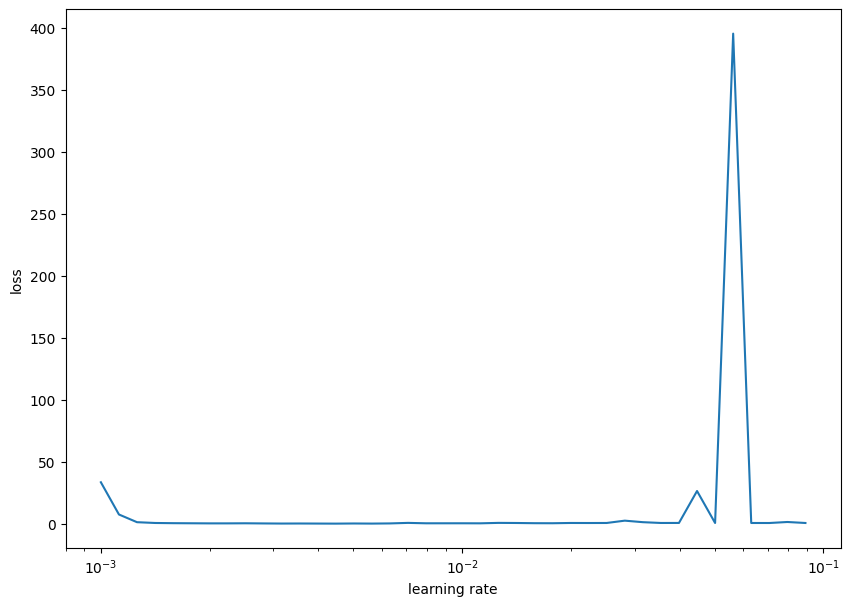

In [19]:
import numpy as np
lrs = 1e-3 * (10 **  (np.arange(40)/20))
plt.figure( figsize=(10,7))
plt.semilogx(lrs, find_lr_history.history['loss'])
plt.xlabel("learning rate")
plt.ylabel("loss")

In [35]:
tf.random.set_seed(42)

model4 = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, activation=tf.keras.activations.leaky_relu,kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation=tf.keras.activations.leaky_relu,kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.keras.activations.leaky_relu),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.0032),
              metrics=['accuracy'])



history = model4.fit(train_dataset, validation_data=valid_dataset, epochs=40)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 519ms/step - accuracy: 0.5339 - loss: 233.2451 - val_accuracy: 0.4138 - val_loss: 70.5142
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 0.5551 - loss: 41.6689 - val_accuracy: 0.6034 - val_loss: 32.3506
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - accuracy: 0.6441 - loss: 16.5695 - val_accuracy: 0.6724 - val_loss: 12.4441
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 553ms/step - accuracy: 0.5297 - loss: 18.1446 - val_accuracy: 0.5690 - val_loss: 5.8894
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 529ms/step - accuracy: 0.6398 - loss: 7.7222 - val_accuracy: 0.6034 - val_loss: 8.8149
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 643ms/step - accuracy: 0.7034 - loss: 3.5651 - val_accuracy: 0.6034 - val_loss: 4.4330
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 623ms/step - accuracy: 0.7119 - loss: 3.2386 - val_accuracy: 0.5345 - val_loss: 3.7344
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 686ms/step - accuracy: 0.6992 - loss: 2.1858 - val_accuracy: 0.4655 - v

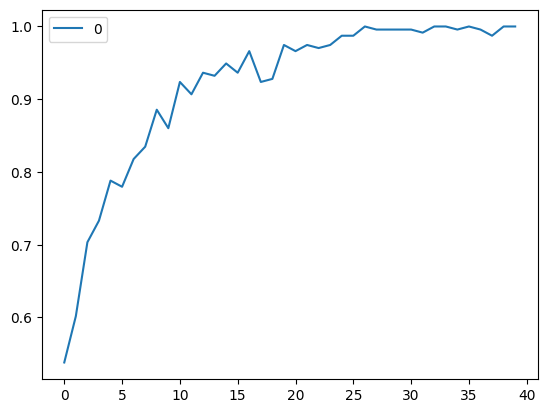

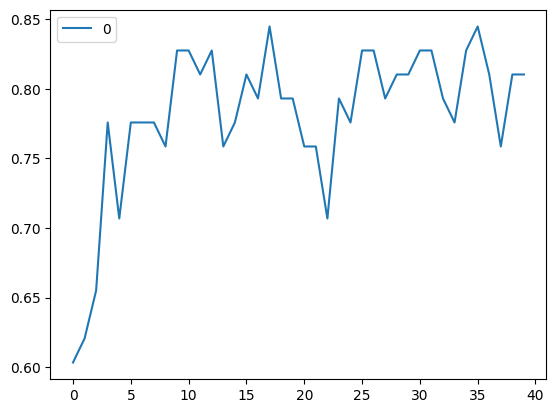

In [23]:
pd.DataFrame(history.history['accuracy']).plot()
pd.DataFrame(history.history['val_accuracy']).plot()
plt.show()

In [33]:
model4.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8247 - loss: 1.2105 


[1.2104722261428833, 0.8247422575950623]

In [18]:
model4.predict(test_dataset).round()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],